<a href="https://colab.research.google.com/github/tobiasllop/Tesis/blob/main/Tesis_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib as plt
import pyarrow.parquet as pq
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Exploracion de Datos


In [8]:
"""
explorar_distribucion.py
========================
Tesis 2026 - Tobias Llop

PASO PREVIO: explorar la distribución de prestamos en personas físicas
para elegir los cortes de clasificación con criterio.

Corre esto ANTES de clasificacion_deudores.py.
No acumula filas en RAM: agrega on-the-fly con ParquetWriter.
"""

import gc
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

FILE_PATH       = "/content/drive/MyDrive/Tesis2026/deudores_final_enero.parquet"
OUTPUT_DIR      = Path("/content/drive/MyDrive/Tesis2026/clasificacion_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
INTER_PATH      = OUTPUT_DIR / "_tmp_exploracion.parquet"
PREFIJOS_FISICAS = ("20", "23", "24", "27")
COLS_LEER       = ["cod_entidad", "tipo_id", "nro_id", "prestamos"]
BATCH_SIZE      = 50_000

# ─────────────────────────────────────────────
# 1. Agregar on-the-fly → parquet intermedio
# ─────────────────────────────────────────────

print("Agregando datos (pasada única)...")

schema = pa.schema([
    pa.field("cod_entidad",   pa.string()),
    pa.field("nro_id",        pa.string()),
    pa.field("prestamos_sum", pa.float64()),
])

writer        = pq.ParquetWriter(str(INTER_PATH), schema=schema)
total_scanned = 0
total_fisicas = 0

for batch in pq.ParquetFile(FILE_PATH).iter_batches(batch_size=BATCH_SIZE, columns=COLS_LEER):
    chunk = batch.to_pandas()
    total_scanned += len(chunk)
    chunk["tipo_id"] = chunk["tipo_id"].astype(str)
    chunk["nro_id"]  = chunk["nro_id"].astype(str)
    mask    = (chunk["tipo_id"] == "11") & chunk["nro_id"].str.startswith(PREFIJOS_FISICAS)
    fisicas = chunk.loc[mask, ["cod_entidad", "nro_id", "prestamos"]].copy()
    del chunk; gc.collect()
    if fisicas.empty:
        del fisicas; continue
    total_fisicas += len(fisicas)
    fisicas["prestamos"] = pd.to_numeric(fisicas["prestamos"], errors="coerce").fillna(0)
    mini = fisicas.groupby(["cod_entidad", "nro_id"], as_index=False).agg(
        prestamos_sum=("prestamos", "sum"))
    mini["cod_entidad"] = mini["cod_entidad"].astype(str)
    mini["nro_id"]      = mini["nro_id"].astype(str)
    writer.write_table(pa.Table.from_pandas(mini, schema=schema, preserve_index=False))
    del fisicas, mini; gc.collect()
    if total_scanned % 1_000_000 == 0:
        print(f"  {total_scanned:,} escaneadas...")

writer.close()
print(f"✓ Físicas encontradas: {total_fisicas:,}")

# ─────────────────────────────────────────────
# 2. Leer intermedio y agrupar final
# ─────────────────────────────────────────────

df = (pq.read_table(str(INTER_PATH)).to_pandas()
      .groupby(["cod_entidad", "nro_id"], as_index=False)
      .agg(deuda_total=("prestamos_sum", "sum")))
INTER_PATH.unlink(missing_ok=True)

deuda = df["deuda_total"]
con_deuda = deuda[deuda > 0]

print(f"\n✓ Deudores únicos      : {len(df):,}")
print(f"  Con prestamos > 0    : {len(con_deuda):,}  ({100*len(con_deuda)/len(df):.1f}%)")
print(f"  Con prestamos = 0    : {(deuda == 0).sum():,}  ({100*(deuda==0).sum()/len(df):.1f}%)")


Agregando datos (pasada única)...
  1,000,000 escaneadas...
  2,000,000 escaneadas...
  3,000,000 escaneadas...
  4,000,000 escaneadas...
  5,000,000 escaneadas...
  6,000,000 escaneadas...
  7,000,000 escaneadas...
  8,000,000 escaneadas...
  9,000,000 escaneadas...
  10,000,000 escaneadas...
  11,000,000 escaneadas...
  12,000,000 escaneadas...
  13,000,000 escaneadas...
  14,000,000 escaneadas...
  15,000,000 escaneadas...
  16,000,000 escaneadas...
  17,000,000 escaneadas...
  18,000,000 escaneadas...
  19,000,000 escaneadas...
  20,000,000 escaneadas...
  21,000,000 escaneadas...
  22,000,000 escaneadas...
  23,000,000 escaneadas...
  24,000,000 escaneadas...
  25,000,000 escaneadas...
  26,000,000 escaneadas...
  27,000,000 escaneadas...
  28,000,000 escaneadas...
  29,000,000 escaneadas...
  30,000,000 escaneadas...
  31,000,000 escaneadas...
  32,000,000 escaneadas...
  33,000,000 escaneadas...
  34,000,000 escaneadas...
  35,000,000 escaneadas...
  36,000,000 escaneadas...
  3

In [ ]:

# ─────────────────────────────────────────────
# 3. Estadísticas descriptivas completas
# ─────────────────────────────────────────────

pcts = [10, 20, 25, 33, 50, 66, 75, 80, 90, 95, 99, 99.9]
vals = np.percentile(con_deuda, pcts)

print("\n" + "=" * 50)
print("DISTRIBUCIÓN DE PRÉSTAMOS (deudores con deuda > 0)")
print("=" * 50)
print(f"  N          : {len(con_deuda):>15,}")
print(f"  Media      : ${con_deuda.mean():>15,.0f}")
print(f"  Mediana    : ${con_deuda.median():>15,.0f}")
print(f"  Desvío std : ${con_deuda.std():>15,.0f}")
print(f"  Mínimo     : ${con_deuda.min():>15,.0f}")
print(f"  Máximo     : ${con_deuda.max():>15,.0f}")
print(f"\n  {'Percentil':>10}   {'Valor':>15}")
print(f"  {'-'*28}")
for p, v in zip(pcts, vals):
    print(f"  p{p:>6.1f}   :  ${v:>15,.0f}")

# Concentración tipo Pareto
total = con_deuda.sum()
for pct_n in [10, 20]:
    umbral = np.percentile(con_deuda, 100 - pct_n)
    monto  = con_deuda[con_deuda >= umbral].sum()
    print(f"\n  → El top {pct_n}% de deudores concentra el {100*monto/total:.1f}% del monto total")

# ─────────────────────────────────────────────
# 4. Gráficos para elegir los cortes visualmente
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploración de Préstamos — Personas Físicas — Enero 2026",
             fontsize=13, fontweight="bold")

# --- Histograma escala log ---
ax = axes[0]
log_vals = np.log10(con_deuda + 1)
ax.hist(log_vals, bins=80, color="#2196F3", alpha=0.75, edgecolor="white", linewidth=0.2)
ax.set_xlabel("log₁₀(Préstamos + 1)", fontsize=11)
ax.set_ylabel("Cantidad de Deudores", fontsize=11)
ax.set_title("Histograma (escala log)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

def log_to_label(x):
    val = 10 ** x
    if val >= 1e9: return f"${val/1e9:.0f}B"
    if val >= 1e6: return f"${val/1e6:.0f}M"
    if val >= 1e3: return f"${val/1e3:.0f}K"
    return f"${val:.0f}"

xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([log_to_label(x) for x in xticks], rotation=30, ha="right", fontsize=8)

# Líneas de percentiles clave
for p, v, color in [(33, np.percentile(con_deuda,33), "#FF9800"),
                    (66, np.percentile(con_deuda,66), "#F44336"),
                    (90, np.percentile(con_deuda,90), "#9C27B0")]:
    ax.axvline(np.log10(v+1), color=color, linestyle="--", linewidth=1.2,
               label=f"p{p}=${v:,.0f}")
ax.legend(fontsize=8)

# --- Curva de Lorenz (concentración) ---
ax2 = axes[1]
sorted_vals = np.sort(con_deuda.values)
cum_deudores = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
cum_monto    = np.cumsum(sorted_vals) / sorted_vals.sum()
ax2.plot(cum_deudores * 100, cum_monto * 100, color="#F44336", linewidth=2, label="Lorenz")
ax2.plot([0, 100], [0, 100], "k--", linewidth=1, alpha=0.5, label="Igualdad perfecta")
ax2.fill_between(cum_deudores * 100, cum_deudores * 100, cum_monto * 100,
                 alpha=0.15, color="#F44336")
ax2.set_xlabel("% Deudores acumulados", fontsize=11)
ax2.set_ylabel("% Monto acumulado", fontsize=11)
ax2.set_title("Curva de Lorenz\n(concentración del monto)", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Marcar los cortes p66/p90 en Lorenz
for p, color in [(66, "#F44336"), (90, "#9C27B0")]:
    idx = int(p / 100 * len(cum_monto))
    ax2.axvline(p, color=color, linestyle=":", linewidth=1.2, alpha=0.8)
    ax2.text(p + 0.5, cum_monto[idx] * 100 - 5, f"p{p}\n({cum_monto[idx]*100:.0f}% monto)",
             fontsize=7, color=color)

# --- Boxplot ---
ax3 = axes[2]
bp = ax3.boxplot(np.log10(con_deuda.clip(lower=1)), patch_artist=True,
                 medianprops=dict(color="black", linewidth=2),
                 flierprops=dict(marker=".", markersize=1, alpha=0.3))
bp["boxes"][0].set_facecolor("#2196F3")
bp["boxes"][0].set_alpha(0.7)
ax3.set_ylabel("log₁₀(Préstamos)", fontsize=11)
ax3.set_title("Boxplot\n(identifica outliers)", fontsize=12)
ax3.set_xticklabels(["Todas las físicas"])
yticks = ax3.get_yticks()
ax3.set_yticks(yticks)
ax3.set_yticklabels([log_to_label(y) for y in yticks], fontsize=9)

plt.tight_layout()
fig_path = OUTPUT_DIR / "exploracion_distribucion.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✓ Gráfico guardado: {fig_path}")
print("\n" + "=" * 55)
print("CON ESTA INFO PODÉS ELEGIR LOS CORTES:")
print("  - Mirá el histograma: ¿hay 'valles naturales'?")
print("  - Mirá Lorenz: el top 10% concentra ¿qué % del monto?")
print("  - Luego editá P_BAJO y P_ALTO en clasificacion_deudores.py")
print("=" * 55)


DISTRIBUCIÓN DE PRÉSTAMOS (deudores con deuda > 0)
  N          :      38,158,916
  Media      : $          2,211
  Mediana    : $            574
  Desvío std : $         13,811
  Mínimo     : $              1
  Máximo     : $     29,151,144

   Percentil             Valor
  ----------------------------
  p  10.0   :  $             63
  p  20.0   :  $            127
  p  25.0   :  $            173
  p  33.0   :  $            268
  p  50.0   :  $            574
  p  66.0   :  $          1,114
  p  75.0   :  $          1,675
  p  80.0   :  $          2,147
  p  90.0   :  $          4,192
  p  95.0   :  $          7,286
  p  99.0   :  $         21,715
  p  99.9   :  $        148,796

  → El top 10% de deudores concentra el 65.9% del monto total

  → El top 20% de deudores concentra el 79.4% del monto total


# Asignacion de clases


PASO 1: Filtrando y agregando on-the-fly (bajo consumo RAM)...
  Escaneadas: 1,000,000  |  Físicas acumuladas: 1,000,000
  Escaneadas: 2,000,000  |  Físicas acumuladas: 2,000,000
  Escaneadas: 3,000,000  |  Físicas acumuladas: 2,864,118
  Escaneadas: 4,000,000  |  Físicas acumuladas: 3,864,118
  Escaneadas: 5,000,000  |  Físicas acumuladas: 4,830,330
  Escaneadas: 6,000,000  |  Físicas acumuladas: 5,830,330
  Escaneadas: 7,000,000  |  Físicas acumuladas: 6,809,054
  Escaneadas: 8,000,000  |  Físicas acumuladas: 7,793,264
  Escaneadas: 9,000,000  |  Físicas acumuladas: 8,793,264
  Escaneadas: 10,000,000  |  Físicas acumuladas: 9,753,247
  Escaneadas: 11,000,000  |  Físicas acumuladas: 10,734,346
  Escaneadas: 12,000,000  |  Físicas acumuladas: 11,720,655
  Escaneadas: 13,000,000  |  Físicas acumuladas: 12,720,655
  Escaneadas: 14,000,000  |  Físicas acumuladas: 13,671,165
  Escaneadas: 15,000,000  |  Físicas acumuladas: 14,635,352
  Escaneadas: 16,000,000  |  Físicas acumuladas: 15,635,

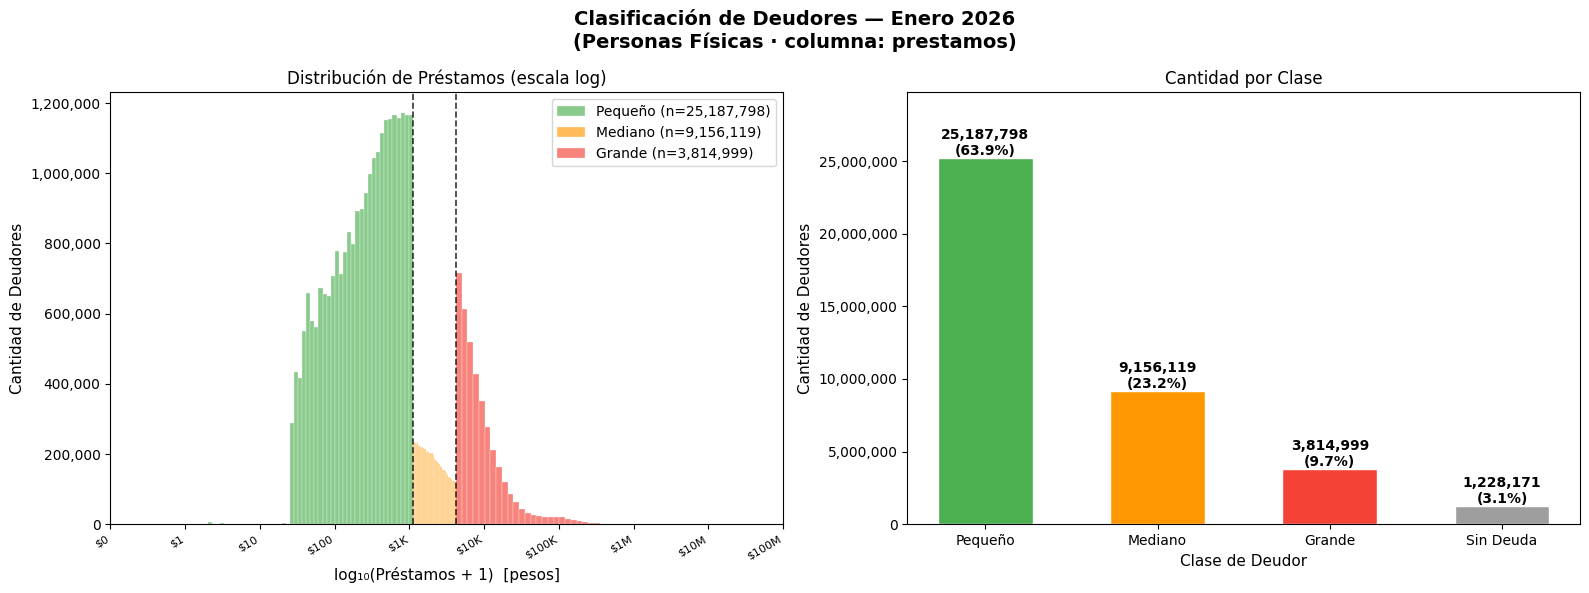

✓ Histograma guardado: /content/drive/MyDrive/Tesis2026/clasificacion_output/histograma_clasificacion.png


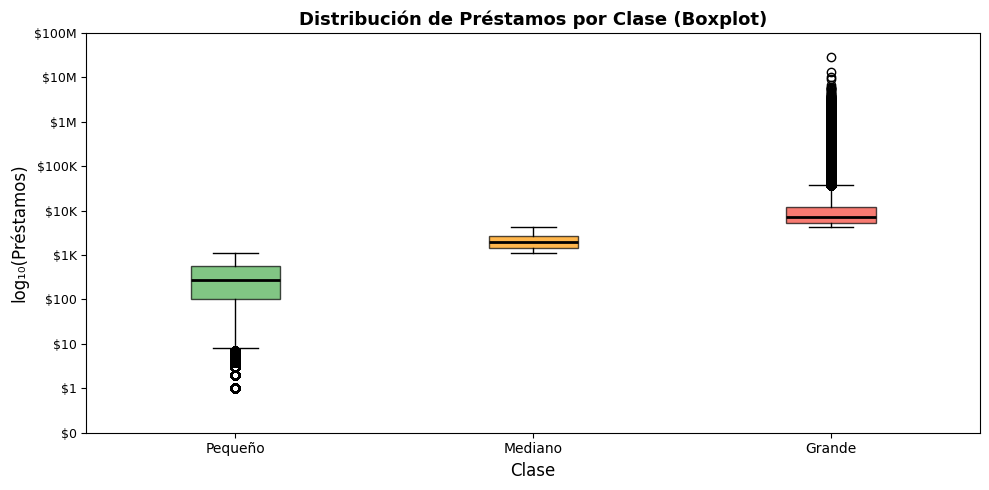

✓ Boxplot guardado: /content/drive/MyDrive/Tesis2026/clasificacion_output/boxplot_por_clase.png

PASO 5: Estadísticas descriptivas por clase


In [ ]:
"""
clasificacion_deudores.py
=========================
Tesis 2026 - Tobias Llop

MÉTODO DE CLASIFICACIÓN: PERCENTIL (p66 / p90)
-----------------------------------------------
Se usa percentil porque la distribución de préstamos bancarios es
altamente asimétrica (pocos deudores concentran montos muy grandes).
Los cortes se calculan SOLO sobre deudores con prestamos > 0:

  Pequeño : 0  < prestamos ≤ p66   (~66% de los deudores con deuda)
  Mediano : p66 < prestamos ≤ p90
  Grande  : prestamos > p90         (top 10% de mayor exposición)
  Sin Deuda: prestamos == 0

ESTRATEGIA DE MEMORIA (dos pasadas, sin concat grande):
  Pasada 1 → agrega on-the-fly por batch → escribe parquet intermedio
             con ParquetWriter (igual que txt_to_parquet.ipynb)
  Pasada 2 → lee el parquet intermedio (pequeño), calcula percentiles,
             asigna clase y genera gráficos
"""

import gc
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 0. CONFIGURACIÓN
# ─────────────────────────────────────────────

FILE_PATH    = "/content/drive/MyDrive/Tesis2026/deudores_final_enero.parquet"
OUTPUT_DIR   = Path("/content/drive/MyDrive/Tesis2026/clasificacion_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Parquet intermedio: solo las claves + suma prestamos (muy pequeño)
INTER_PATH   = OUTPUT_DIR / "_tmp_agg_fisicas.parquet"
# Output final
OUT_PARQUET  = OUTPUT_DIR / "deudores_fisicas_clasificados_enero.parquet"

BATCH_SIZE       = 50_000

# ── Percentiles de corte ────────────────────
# Ajustá estos valores DESPUÉS de correr explorar_distribucion.py
P_BAJO = 66   # corte Pequeño/Mediano
P_ALTO = 90   # corte Mediano/Grande
PREFIJOS_FISICAS = ("20", "23", "24", "27")
COLS_LEER       = ["cod_entidad", "tipo_id", "nro_id", "prestamos"]

# ─────────────────────────────────────────────
# PASADA 1: filtrar + agregar + escribir parquet intermedio
# Nunca se acumula nada en RAM: cada batch se agrega y se escribe
# ─────────────────────────────────────────────

print("=" * 60)
print("PASADA 1: Filtrando, agregando y escribiendo parquet intermedio...")
print("=" * 60)

schema_inter = pa.schema([
    pa.field("cod_entidad",   pa.string()),
    pa.field("nro_id",        pa.string()),
    pa.field("prestamos_sum", pa.float64()),
])

parquet_src = pq.ParquetFile(FILE_PATH)
writer      = pq.ParquetWriter(str(INTER_PATH), schema=schema_inter)

total_scanned = 0
total_fisicas = 0

for batch in parquet_src.iter_batches(batch_size=BATCH_SIZE, columns=COLS_LEER):
    chunk = batch.to_pandas()
    total_scanned += len(chunk)

    chunk["tipo_id"] = chunk["tipo_id"].astype(str)
    chunk["nro_id"]  = chunk["nro_id"].astype(str)

    mask    = (chunk["tipo_id"] == "11") & chunk["nro_id"].str.startswith(PREFIJOS_FISICAS)
    fisicas = chunk.loc[mask, ["cod_entidad", "nro_id", "prestamos"]].copy()

    del chunk
    gc.collect()

    if fisicas.empty:
        del fisicas
        continue

    total_fisicas += len(fisicas)
    fisicas["prestamos"] = pd.to_numeric(fisicas["prestamos"], errors="coerce").fillna(0)

    mini = (
        fisicas
        .groupby(["cod_entidad", "nro_id"], as_index=False)
        .agg(prestamos_sum=("prestamos", "sum"))
    )
    mini["cod_entidad"] = mini["cod_entidad"].astype(str)
    mini["nro_id"]      = mini["nro_id"].astype(str)

    writer.write_table(pa.Table.from_pandas(mini, schema=schema_inter, preserve_index=False))

    del fisicas, mini
    gc.collect()

    if total_scanned % 1_000_000 == 0:
        print(f"  Escaneadas: {total_scanned:,}  |  Físicas: {total_fisicas:,}")

writer.close()
print(f"\n✓ Escaneadas  : {total_scanned:,}")
print(f"✓ Físicas     : {total_fisicas:,}")
print(f"✓ Intermedio  : {INTER_PATH}")

# ─────────────────────────────────────────────
# PASADA 2: leer intermedio → agrupar final → clasificar
# El parquet intermedio es mucho más chico (solo claves + un float)
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("PASADA 2: Agrupación final y clasificación...")
print("=" * 60)

df_inter = pq.read_table(str(INTER_PATH)).to_pandas()

df_deudores = (
    df_inter
    .groupby(["cod_entidad", "nro_id"], as_index=False)
    .agg(deuda_total=("prestamos_sum", "sum"))
)
del df_inter
gc.collect()

print(f"✓ Deudores únicos: {len(df_deudores):,}")
print(f"  Con prestamos > 0: {(df_deudores['deuda_total'] > 0).sum():,}")
print(f"  Con prestamos = 0: {(df_deudores['deuda_total'] == 0).sum():,}")

# ── Clasificación por PERCENTIL p66/p90 ──────
mask_pos  = df_deudores["deuda_total"] > 0
deuda_pos = df_deudores.loc[mask_pos, "deuda_total"]

p66 = np.percentile(deuda_pos, P_BAJO)
p90 = np.percentile(deuda_pos, P_ALTO)
cortes = [0, p66, p90, np.inf]
labels = ["Pequeño", "Mediano", "Grande"]

df_deudores["clase"] = "Sin Deuda"
df_deudores.loc[mask_pos, "clase"] = pd.cut(
    deuda_pos, bins=cortes, labels=labels, right=True,
).astype(str)

print(f"\nCortes (método: percentil p{P_BAJO}/p{P_ALTO}):")
print(f"  Pequeño  : $0                →  ${p66:>15,.0f}")
print(f"  Mediano  : ${p66:>15,.0f}  →  ${p90:>15,.0f}")
print(f"  Grande   : ${p90:>15,.0f}  →  ∞")

print("\nDistribución:")
for cls, cnt in df_deudores["clase"].value_counts().items():
    pct = 100 * cnt / len(df_deudores)
    print(f"  {cls:10s}: {cnt:>8,}  ({pct:.1f}%)")

# ─────────────────────────────────────────────
# HISTOGRAMAS
# ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("Generando histogramas...")
print("=" * 60)

COLORES = {"Pequeño": "#4CAF50", "Mediano": "#FF9800",
           "Grande": "#F44336", "Sin Deuda": "#9E9E9E"}

def log_to_label(x):
    val = 10 ** x
    if val >= 1e9: return f"${val/1e9:.0f}B"
    if val >= 1e6: return f"${val/1e6:.0f}M"
    if val >= 1e3: return f"${val/1e3:.0f}K"
    return f"${val:.0f}"

df_con_deuda = df_deudores[mask_pos]

# Fig 1: histograma log + barras de conteo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Clasificación de Deudores — Enero 2026\n(Personas Físicas · Método: Percentil p66/p90)",
    fontsize=14, fontweight="bold",
)

ax = axes[0]
for clase in labels:
    sub = df_con_deuda[df_con_deuda["clase"] == clase]["deuda_total"]
    if len(sub):
        ax.hist(np.log10(sub + 1), bins=50, alpha=0.65,
                color=COLORES[clase], label=f"{clase} (n={len(sub):,})",
                edgecolor="white", linewidth=0.3)

for corte in [p66, p90]:
    ax.axvline(np.log10(corte + 1), color="black",
               linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_xlabel("log₁₀(Préstamos + 1)  [pesos]", fontsize=11)
ax.set_ylabel("Cantidad de Deudores", fontsize=11)
ax.set_title("Distribución de Préstamos (escala log)", fontsize=12)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([log_to_label(x) for x in xticks], rotation=30, ha="right", fontsize=8)

ax2 = axes[1]
clase_counts = (df_deudores["clase"].value_counts()
                .reindex(["Pequeño", "Mediano", "Grande", "Sin Deuda"]).fillna(0))
bars = ax2.bar(clase_counts.index, clase_counts.values,
               color=[COLORES[c] for c in clase_counts.index],
               edgecolor="white", width=0.55)
for bar, val in zip(bars, clase_counts.values):
    pct = 100 * val / len(df_deudores)
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             f"{int(val):,}\n({pct:.1f}%)",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_xlabel("Clase de Deudor", fontsize=11)
ax2.set_ylabel("Cantidad de Deudores", fontsize=11)
ax2.set_title("Cantidad por Clase", fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.set_ylim(0, clase_counts.max() * 1.18)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "histograma_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Fig 2: boxplot
fig2, ax3 = plt.subplots(figsize=(10, 5))
data_box = [np.log10(df_deudores[df_deudores["clase"] == cls]["deuda_total"].clip(lower=1))
            for cls in labels]
bp = ax3.boxplot(data_box, labels=labels, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))
for patch, cls in zip(bp["boxes"], labels):
    patch.set_facecolor(COLORES[cls])
    patch.set_alpha(0.7)
ax3.set_xlabel("Clase", fontsize=12)
ax3.set_ylabel("log₁₀(Préstamos)", fontsize=12)
ax3.set_title("Distribución de Préstamos por Clase (Boxplot)", fontsize=13, fontweight="bold")
yticks = ax3.get_yticks()
ax3.set_yticks(yticks)
ax3.set_yticklabels([log_to_label(y) for y in yticks], fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "boxplot_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# ESTADÍSTICAS + EXPORTAR
# ─────────────────────────────────────────────

print("\n--- Estadísticas por clase ---")
stats = (df_deudores[mask_pos].groupby("clase")["deuda_total"]
         .agg(n="count", media="mean", mediana="median",
              min="min", max="max", suma="sum")
         .reindex(labels))
for col in ["media", "mediana", "min", "max", "suma"]:
    stats[col] = stats[col].apply(lambda x: f"${x:,.0f}")
print(stats.to_string())

print("\n--- Concentración de préstamos ---")
total = df_deudores["deuda_total"].sum()
for cls in labels:
    s = df_deudores[df_deudores["clase"] == cls]["deuda_total"].sum()
    print(f"  {cls:10s}: ${s:>20,.0f}  ({100*s/total:.1f}%)")

df_deudores.to_parquet(str(OUT_PARQUET), index=False)
print(f"\n✓ Parquet final → {OUT_PARQUET}")

# Borrar intermedio
INTER_PATH.unlink(missing_ok=True)
print("✓ Archivo temporal eliminado")
print(f"\n{'='*60}\nPROCESO COMPLETADO\n{'='*60}")